In [23]:
import pandas as pd

In [24]:
import numpy as np

In [25]:
import matplotlib.pyplot as plt

In [55]:
import seaborn as sns

In [56]:
from sklearn.preprocessing import MinMaxScaler

In [27]:
%matplotlib inline

In [28]:
df = pd.read_csv("/Users/senuja/Jupyter Notebook/Video_Game_Sales_Predictor/data/raw/vgchartz-2024.csv")

In [29]:
df.head()

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2018-01-03
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2018-01-14


In [30]:
df.dtypes # check data types

img              object
title            object
console          object
genre            object
publisher        object
developer        object
critic_score    float64
total_sales     float64
na_sales        float64
jp_sales        float64
pal_sales       float64
other_sales     float64
release_date     object
last_update      object
dtype: object

In [31]:
df = df.drop(['img','last_update'], axis=1) # remove columns

In [32]:
df.head()

,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,2013-09-17
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06


In [33]:
df = df.rename(columns={"title": "Game Title", "console": "Console",
                        "genre": "Genre", "publisher": "Publisher",
                        "developer": "Developer", "critic_score": "Critic Score",
                        "total_sales": "Sales", "na_sales": "North American Sales",
                        "jp_sales": "Japanese Sales", "pal_sales": "EU Sales", 
                        "other_sales": "Other Sales", "release_date": "Release Date",})  # rename columns

In [34]:
df.shape # check dimentions

(64016, 12)

In [35]:
df.count() # count rows

Game Title              64016
Console                 64016
Genre                   64016
Publisher               64016
Developer               63999
Critic Score             6678
Sales                   18922
North American Sales    12637
Japanese Sales           6726
EU Sales                12824
Other Sales             15128
Release Date            56965
dtype: int64

In [36]:
duplicate_rows_df = df[df.duplicated()]
print("number of duplicate rows: ", duplicate_rows_df.shape)   #check duplicates 

number of duplicate rows:  (21, 12)


In [37]:
df = df.drop_duplicates() # drop duplicates

In [38]:
print(df.isnull().sum()) # missing values ( null )

Game Title                  0
Console                     0
Genre                       0
Publisher                   0
Developer                  17
Critic Score            57317
Sales                   45076
North American Sales    51358
Japanese Sales          57272
EU Sales                51171
Other Sales             48867
Release Date             7051
dtype: int64


In [44]:
# 1. Drop rows with missing target
df = df.dropna(subset=['Sales'])

# 2. Fill categorical with "Unknown"
for col in ['Publisher','Developer','Genre','Console']:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")

# 3. Fill regional sales with 0
for col in ['North American Sales','Japanese Sales','EU Sales','Other Sales']:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# 4. Critic Score -> fill with mean
if 'Critic Score' in df.columns:
    df['Critic Score'] = df['Critic Score'].fillna(df['Critic Score'].mean())

# 5. Release Date -> convert to year, fill missing with median
df['Release Date'] = pd.to_datetime(df['Release Date'], errors='coerce')
df['Release Year'] = df['Release Date'].dt.year
df['Release Year'] = df['Release Year'].fillna(df['Release Year'].median())


In [47]:
df.head()

,Game Title,Console,Genre,Publisher,Developer,Critic Score,Sales,North American Sales,Japanese Sales,EU Sales,Other Sales,Release Date,Release Year
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,2013
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,2014
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,2002
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,2015
5,Call of Duty: Modern Warfare 3,X360,Shooter,Activision,Infinity Ward,8.7,14.82,9.07,0.13,4.29,1.33,2011-11-08,2011


In [46]:
# Parse release_date -> year
df['Release Date'] = pd.to_datetime(df['Release Date'], errors='coerce')
df['Release Year'] = df['Release Date'].dt.year

# Ensure numeric columns are numeric
num_cols = ['Sales','North American Sales','Japanese Sales','EU Sales','Other Sales','Critic Score']
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

df[['Release Date','Release Year']].head()

,Release Date,Release Year
0,2013-09-17,2013
1,2014-11-18,2014
2,2002-10-28,2002
4,2015-11-06,2015
5,2011-11-08,2011


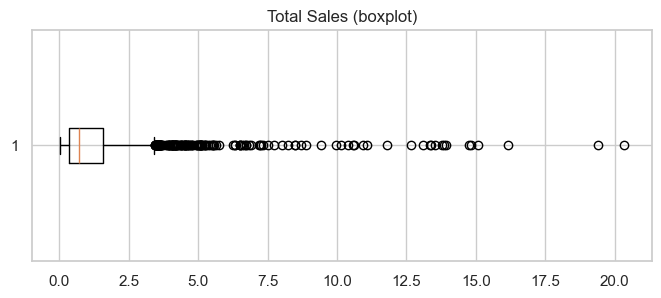

np.float64(13.061300000000035)

In [51]:
# Visualize
plt.figure(figsize=(8,3))
plt.title('Total Sales (boxplot)')
plt.boxplot(df['Sales'].dropna(), vert=False)
plt.show()

# Trim >99th percentile
p99 = df['Sales'].quantile(0.99)
df = df[df['Sales'] <= p99].reset_index(drop=True)
p99

In [52]:
# One-hot encode Genre & Platform
df = pd.get_dummies(df, columns=['Genre','Console'], drop_first=True)

# For Publisher/Developer, keep top 30 and label others as "Other"
def cap_top(series, n=30):
    top = series.value_counts().nlargest(n).index
    return series.where(series.isin(top), "Other")

df['Publisher'] = cap_top(df['Publisher'])
df['Developer'] = cap_top(df['Developer'])

# One-hot encode after capping
df = pd.get_dummies(df, columns=['Publisher','Developer'], drop_first=True)


In [53]:
df.head()

,Game Title,Critic Score,Sales,North American Sales,Japanese Sales,EU Sales,Other Sales,Release Date,Release Year,Genre_Action-Adventure,Genre_Adventure,Genre_Board Game,Genre_Fighting,Genre_MMO,Genre_Misc,Genre_Music,Genre_Party,Genre_Platform,Genre_Puzzle,Genre_Racing,Genre_Role-Playing,Genre_Sandbox,Genre_Shooter,Genre_Simulation,Genre_Sports,Genre_Strategy,Console_DC,Console_DS,Console_GB,Console_GBA,Console_GBC,Console_GC,Console_N64,Console_NES,Console_NS,Console_PS,Console_PS2,Console_PS3,Console_PS4,Console_PSN,Console_PSP,Console_PSV,Console_SAT,Console_Wii,Console_WiiU,Console_X360,Console_XB,Console_XOne,Publisher_2K Sports,Publisher_Activision,Publisher_Aksys Games,Publisher_Atari,Publisher_Atlus,Publisher_Bethesda Softworks,Publisher_Capcom,Publisher_Codemasters,Publisher_D3 Publisher,Publisher_EA Sports,Publisher_Eidos Interactive,Publisher_Electronic Arts,Publisher_KOEI,Publisher_Konami,Publisher_Microsoft Game Studios,Publisher_NIS America,Publisher_Namco,Publisher_Namco Bandai,Publisher_Natsume,Publisher_Nintendo,Publisher_Other,Publisher_Rockstar Games,Publisher_Sega,Publisher_Sony Computer Entertainment,Publisher_Square Enix,Publisher_THQ,Publisher_Tecmo Koei,Publisher_Ubisoft,Publisher_Warner Bros. Interactive,Publisher_Xseed Games,Developer_Atlus,Developer_Bizarre Creations,Developer_Capcom,Developer_Codemasters,Developer_Codemasters Birmingham,Developer_Criterion Games,Developer_EA Black Box,Developer_EA Canada,Developer_EA Tiburon,Developer_From Software,Developer_Hudson Soft,Developer_Infinity Ward,Developer_Intelligent Systems,Developer_Kojima Productions,Developer_Konami,Developer_Konami Computer Entertainment Tokyo,Developer_Namco,Developer_Namco Bandai Games,Developer_Neversoft Entertainment,Developer_Nippon Ichi Software,Developer_Omega Force,Developer_Other,Developer_Sega,Developer_Sonic Team,Developer_Square Enix,Developer_Team Ninja,Developer_Treyarch,Developer_Ubisoft Montreal,Developer_Visual Concepts,Developer_Volition Inc.
0,Call of Duty: Black Ops,8.7,12.67,6.01,0.48,4.40,1.78,2010-11-09,2010,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,FIFA 18,8.3,11.80,1.27,0.15,8.64,1.73,2017-09-29,2017,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
2,Grand Theft Auto IV,10.0,11.09,6.80,0.14,3.11,1.04,2008-04-29,2008,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
3,FIFA 17,8.9,10.94,1.26,0.12,7.95,1.61

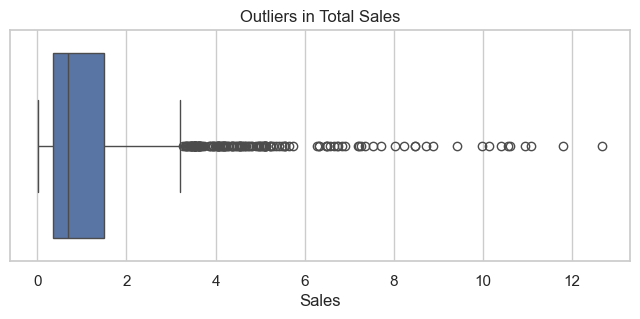

In [54]:
plt.figure(figsize=(8,3))
sns.boxplot(x=df['Sales'])
plt.title("Outliers in Total Sales")
plt.show()

# Trim top 1% to reduce extreme bias
q99 = df['Sales'].quantile(0.99)
df = df[df['Sales'] <= q99].reset_index(drop=True)

In [61]:
# Scale between 0-1 ( Normalization )
scaler = MinMaxScaler()
df[['Sales','Critic Score']] = scaler.fit_transform(df[['Sales','Critic Score']])

In [62]:
df.head()

,Game Title,Critic Score,Sales,North American Sales,Japanese Sales,EU Sales,Other Sales,Release Date,Release Year,Genre_Action-Adventure,Genre_Adventure,Genre_Board Game,Genre_Fighting,Genre_MMO,Genre_Misc,Genre_Music,Genre_Party,Genre_Platform,Genre_Puzzle,Genre_Racing,Genre_Role-Playing,Genre_Sandbox,Genre_Shooter,Genre_Simulation,Genre_Sports,Genre_Strategy,Console_DC,Console_DS,Console_GB,Console_GBA,Console_GBC,Console_GC,Console_N64,Console_NES,Console_NS,Console_PS,Console_PS2,Console_PS3,Console_PS4,Console_PSN,Console_PSP,Console_PSV,Console_SAT,Console_Wii,Console_WiiU,Console_X360,Console_XB,Console_XOne,Publisher_2K Sports,Publisher_Activision,Publisher_Aksys Games,Publisher_Atari,Publisher_Atlus,Publisher_Bethesda Softworks,Publisher_Capcom,Publisher_Codemasters,Publisher_D3 Publisher,Publisher_EA Sports,Publisher_Eidos Interactive,Publisher_Electronic Arts,Publisher_KOEI,Publisher_Konami,Publisher_Microsoft Game Studios,Publisher_NIS America,Publisher_Namco,Publisher_Namco Bandai,Publisher_Natsume,Publisher_Nintendo,Publisher_Other,Publisher_Rockstar Games,Publisher_Sega,Publisher_Sony Computer Entertainment,Publisher_Square Enix,Publisher_THQ,Publisher_Tecmo Koei,Publisher_Ubisoft,Publisher_Warner Bros. Interactive,Publisher_Xseed Games,Developer_Atlus,Developer_Bizarre Creations,Developer_Capcom,Developer_Codemasters,Developer_Codemasters Birmingham,Developer_Criterion Games,Developer_EA Black Box,Developer_EA Canada,Developer_EA Tiburon,Developer_From Software,Developer_Hudson Soft,Developer_Infinity Ward,Developer_Intelligent Systems,Developer_Kojima Productions,Developer_Konami,Developer_Konami Computer Entertainment Tokyo,Developer_Namco,Developer_Namco Bandai Games,Developer_Neversoft Entertainment,Developer_Nippon Ichi Software,Developer_Omega Force,Developer_Other,Developer_Sega,Developer_Sonic Team,Developer_Square Enix,Developer_Team Ninja,Developer_Treyarch,Developer_Ubisoft Montreal,Developer_Visual Concepts,Developer_Volition Inc.
0,Call of Duty: Infinite Warfare,0.700000,1.000000,3.11,0.19,3.83,1.36,2016-11-04,2016,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,Fallout 4,0.800000,1.000000,2.91,0.27,3.97,1.34,2015-11-10,2015,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
2,FIFA 16,0.785714,0.969267,1.15,0.07,5.77,1.23,2015-09-22,2015,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,Star Wars Battlefr

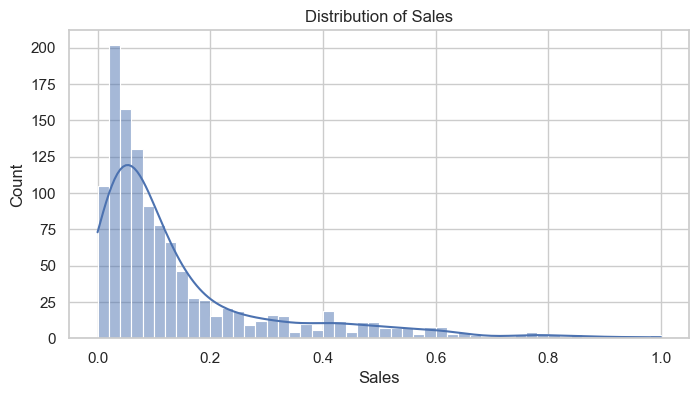

ValueError: Could not interpret value `Genre` for `x`. An entry with this name does not appear in `data`.

<Figure size 1000x500 with 0 Axes>

In [63]:
# 6.1 Histogram: Sales distribution
plt.figure(figsize=(8,4))
sns.histplot(df['Sales'], bins=50, kde=True)
plt.title("Distribution of Sales")
plt.show()

# 6.2 Boxplot: Sales by Genre
plt.figure(figsize=(10,5))
sns.boxplot(x='Genre', y='Sales', data=df)
plt.xticks(rotation=45)
plt.title("Sales by Genre")
plt.show()

# 6.3 Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[['Sales','Critic Score']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation between Sales & Critic Score")
plt.show()

# 6.4 Bar plot: Top 10 publishers by total sales
top_publishers = df.groupby('Publisher')['Sales'].sum().sort_values(ascending=False).head(10)
top_publishers.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Publishers by Sales")
plt.ylabel("Total Sales")
plt.show()